# MSCP-Mamba (balanced sampling): CNN + VSS hybrid with per-scene training

Identical architecture to `mscp_mamba_cdnet2014.ipynb` (CNN encoder -> MSCP block ->
2x VSS Mamba stack -> CNN decoder), with **one fix**: training frames are sampled
**evenly across scenes** (40 per scene for N=200) instead of pooled-proportional,
which under-trained the small `park` scene (~6/200 frames -> park F1 0.46, recall 0.33
in run 1).

```
Input [B,3,240,320]
  CNN Encoder (4 blocks x 5 modules, atrous)   ->  F [B,192,60,80]
  MSCP block (contrast branches, Eq. 6)        ->  Y [B,240,60,80]
  VSS stack: 2 x VSSBlock (SS2D, 4-direction)  ->  Y' [B,240,60,80]
  CNN Decoder + FusionLayers                   ->  logits [B,1,240,320]
```

Notes:
- `CONFIG["sampling"] = "balanced"` (default, this run) or `"pooled"` (run-1 behaviour)
- Checkpoints live in their **own Drive folder** (`mscp_mamba_balanced/`) AND are
  tagged (`last__cnn_mamba_balanced.pt`, ...): fully isolated from run 1's
  `mscp_mamba/` folder; auto-resume only within this run
- Validation split stays proportional to scene size (comparable epoch metric);
  the final eval cell still scores ALL annotated frames per scene
- T4 (sm75) -> pure-PyTorch chunked selective scan (self-verified); sm80+ GPUs
  auto-enable the official CUDA kernels


## 1. Environment & GPU check

In [1]:
# Colab: install deps (skip if present). We do NOT `import kaggle` because the
# kaggle package authenticates (and crashes) on import in notebooks. We only need
# the `kaggle` CLI binary, which is used via subprocess in the download cell.
import sys, subprocess, shutil
def pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
for mod, pkg in [("torch","torch"),("torchvision","torchvision"),
                 ("cv2","opencv-python-headless"),("matplotlib","matplotlib"),
                 ("pandas","pandas"),("nbformat","nbformat")]:
    try:
        __import__(mod)
    except ImportError:
        pip(pkg)
# ensure the kaggle CLI is installed WITHOUT importing the package
if not shutil.which("kaggle"):
    pip("kaggle")
import torch, torchvision, cv2
import numpy as np, matplotlib.pyplot as plt, glob, os, random, math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# --- Mamba selective-scan kernels -------------------------------------------
# Official CUDA kernels (mamba-ssm) only run on sm80+ (A100/L4). Colab T4/P100
# fall back to the pure-PyTorch chunked scan implemented later in this notebook.
MAMBA_FAST = False
if device.type == "cuda" and torch.cuda.get_device_capability()[0] >= 8:
    try:
        pip("mamba-ssm")          # compiles CUDA kernels; guarded (can take minutes)
    except Exception as e:
        print("mamba-ssm install failed -> pure-PyTorch fallback |", e)
try:
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn as _sel_scan_fn
    MAMBA_FAST = True
except Exception:
    MAMBA_FAST = False
print("MAMBA_FAST (official CUDA kernels):", MAMBA_FAST,
      "| GPU:", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

torch 2.11.0+cu128 | device: cuda
MAMBA_FAST (official CUDA kernels): False | GPU: Tesla T4


## 2. Kaggle authentication

In [ ]:
# --- Kaggle authentication ---
# Works on Colab WEB, VS Code (Colab runtime), or local. Fill in ONE option.
import os, json
KAGGLE_DIR = os.path.expanduser("~/.kaggle")
os.makedirs(KAGGLE_DIR, exist_ok=True)

# >>> OPTION 1 (simplest, works everywhere incl. VS Code): paste your values <<<
KAGGLE_API_TOKEN = ""    # e.g. "KGAT_xxxxxxxx"   (new token)
KAGGLE_USERNAME  = ""    # legacy kaggle.json username
KAGGLE_KEY       = ""    # legacy kaggle.json key

# OPTION 2: Colab WEB Secrets (the key icon) -- skipped automatically in VS Code
try:
    from google.colab import userdata
    KAGGLE_API_TOKEN = KAGGLE_API_TOKEN or userdata.get("KAGGLE_API_TOKEN")
    KAGGLE_USERNAME  = KAGGLE_USERNAME  or userdata.get("KAGGLE_USERNAME")
    KAGGLE_KEY       = KAGGLE_KEY       or userdata.get("KAGGLE_KEY")
except Exception:
    pass

# OPTION 3: environment variables / files already on disk
KAGGLE_API_TOKEN = KAGGLE_API_TOKEN or os.environ.get("KAGGLE_API_TOKEN")
KAGGLE_USERNAME  = KAGGLE_USERNAME  or os.environ.get("KAGGLE_USERNAME")
KAGGLE_KEY       = KAGGLE_KEY       or os.environ.get("KAGGLE_KEY")
at_path = os.path.join(KAGGLE_DIR, "access_token")
kj_path = os.path.join(KAGGLE_DIR, "kaggle.json")
if not KAGGLE_API_TOKEN and os.path.exists(at_path):
    KAGGLE_API_TOKEN = open(at_path).read().strip()
if not (KAGGLE_USERNAME and KAGGLE_KEY) and os.path.exists(kj_path):
    d = json.load(open(kj_path)); KAGGLE_USERNAME = d.get("username"); KAGGLE_KEY = d.get("key")

assert KAGGLE_API_TOKEN or (KAGGLE_USERNAME and KAGGLE_KEY), (
    "\n*** No Kaggle credentials found. Fill in OPTION 1 above (paste your token / username+key).")

# Write whichever credential we have so the `kaggle` CLI can use it
if KAGGLE_API_TOKEN:
    open(at_path, "w").write(KAGGLE_API_TOKEN); os.chmod(at_path, 0o600)
    print("Wrote access token ->", at_path)
if KAGGLE_USERNAME and KAGGLE_KEY:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, open(kj_path, "w"))
    os.chmod(kj_path, 0o600)
    print("Wrote kaggle.json ->", kj_path)

Wrote kaggle.json -> /root/.kaggle/kaggle.json


## 2b. Persistent checkpoints on Google Drive (survives runtime resets)

In [3]:
# --- Mount Drive for per-epoch checkpoints (auto-resume after a Colab reset) ---
import os
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/mscp_mamba_balanced"
    print("Drive mounted ->", DRIVE_DIR)
except ModuleNotFoundError:          # running locally / VS Code: fall back to disk
    DRIVE_DIR = os.path.abspath("./outputs/drive")
    print("No Colab Drive -> local checkpoint dir:", DRIVE_DIR)
os.makedirs(DRIVE_DIR, exist_ok=True)

Mounted at /content/drive
Drive mounted -> /content/drive/MyDrive/mscp_mamba_balanced


## 3. Download CDnet 2014 + verify the thermal subset

In [4]:
DATA_ROOT = "./data"
if not os.path.isdir(os.path.join(DATA_ROOT, "dataset")):
    os.makedirs(DATA_ROOT, exist_ok=True)
    print("Downloading CDnet 2014 from Kaggle (large; may take a few minutes)...")
    r = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "maamri95/cdnet2014",
         "-p", DATA_ROOT, "--unzip"],
        capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-2000:]); print("STDERR:", r.stderr[-2000:])
        raise RuntimeError("Kaggle download failed. Check credentials in the previous cell.")
    print("Download complete.")
else:
    print("Dataset already present, skipping download.")

THERMAL = os.path.join(DATA_ROOT, "dataset", "thermal")
assert os.path.isdir(THERMAL), (
    "Thermal category missing in this Kaggle copy. Inspect ./data/dataset; "
    "fall back to another CDnet2014 mirror if needed.")
SCENES = sorted([d for d in os.listdir(THERMAL) if os.path.isdir(os.path.join(THERMAL, d))])
print("Thermal scenes:", SCENES)

s0 = os.path.join(THERMAL, SCENES[0]) 
roi = cv2.imread(os.path.join(s0, "ROI.bmp"), cv2.IMREAD_UNCHANGED)
gts = sorted(glob.glob(os.path.join(s0, "groundtruth", "*.png")))
gt0 = cv2.imread(gts[0], cv2.IMREAD_UNCHANGED)
print("ROI unique:", np.unique(roi)[:8], "| GT unique:", np.unique(gt0)[:8])
print("GT frames in %s:" % SCENES[0], len(gts))

Download complete.
Thermal scenes: ['corridor', 'diningRoom', 'lakeSide', 'library', 'park']
ROI unique: [255] | GT unique: [85]
GT frames in corridor: 5400


## 4. Configuration (all hyperparameters from Sec. IV-A)

In [5]:
CONFIG = dict(
    arch          = "cnn_mamba",  # "cnn" (paper baseline) | "cnn_mamba" (hybrid, this notebook)
    sampling      = "balanced",  # "balanced": n_train split EVENLY across scenes (this run)
                                 # "pooled":   run-1 behaviour (proportional to scene size)
    n_vss         = 2,        # VSS (Mamba) blocks after the MSCP block
    vss_expand    = 2,        # SS2D channel expansion inside a VSS block (d_inner = 2*240)
    vss_d_state   = 16,       # SSM state size N
    scan_chunk    = 64,       # chunk length for the pure-PyTorch selective scan
    in_channels   = 3,        # thermal frames loaded as RGB (replicated grayscale)
    img_size      = (240, 320),  # H,W divisible by 16 so H/4 is exact
    n_train       = 200,      # N = 200 training frames (paper)
    val_frac      = 0.10,     # 10% validation split (paper: 90/10)
    batch_size    = 1,        # paper uses batch=1 (acts as regularization)
    lr            = 1e-4,     # RMSprop initial lr (arch="cnn", paper Sec. IV-A)
    rmsprop_rho   = 0.9,      # RMSProp moving-average decay
    rmsprop_eps   = 1e-8,
    adamw_lr      = 5e-4,     # AdamW initial lr (arch="cnn_mamba"; standard for SSMs)
    adam_wd       = 0.05,     # AdamW weight decay (excludes norms/SSM state)
    lr_decay_factor = 0.1,    # lr x0.1 if val metric stalls 5 epochs
    lr_decay_patience = 5,
    max_epochs    = 100,
    early_stop_patience = 10,
    threshold     = 0.9,      # pixel decision threshold (paper, Sec. III-C)
    sd_rate       = 0.25,     # spatial-dropout rate
    seed          = SEED,
)

## 5. Dataset class (frame<->GT pairing, ROI mask, class weights)

In [6]:
class CDDnetThermal(torch.utils.data.Dataset):
    """Loads CDnet2014 thermal scenes. CDnet GT encoding:
       0   -> background, 85 -> shadow (treat as background),
       170 -> unknown / out of ROI (IGNORE), 255 -> foreground.

       Sampling (train split):
         balanced=True  -> n frames split EVENLY across scenes (n//n_scenes each).
                           Fixes under-training of small scenes (e.g. 'park' drew
                           only ~6/200 frames under pooled sampling in run 1).
         balanced=False -> legacy behaviour: first n of the globally shuffled
                           pool (proportional to scene sizes).
       Val split: val_frac tail of EVERY scene (proportional to scene size) in
       both modes; val_frac=1.0 -> all annotated frames (final evaluation)."""
    def __init__(self, scene_dirs, size, n=None, val_frac=0.1, split="train",
                 seed=42, balanced=True):
        self.size = size  # (H,W)
        rng = np.random.RandomState(seed)
        by_scene = {}                      # scene name -> [(frame, gt, roi), ...]
        for sd in scene_dirs:
            # input folder: 'input' (official) or 'in'
            in_dir = os.path.join(sd, "input")
            if not os.path.isdir(in_dir):
                cand = [c for c in glob.glob(os.path.join(sd, "*")) if os.path.isdir(c)
                        and os.path.basename(c).lower() in ("in",)]
                in_dir = cand[0] if cand else sd
            frames = sorted(glob.glob(os.path.join(in_dir, "*.jpg")) +
                            glob.glob(os.path.join(in_dir, "*.png")))
            spairs = []
            for f in frames:
                idx = int("".join(ch for ch in os.path.basename(f).split(".")[0] if ch.isdigit()))
                gt = os.path.join(sd, "groundtruth", ("gt%06d.png" % idx))
                if os.path.exists(gt):
                    spairs.append((f, gt, os.path.join(sd, "ROI.bmp")))
            if spairs:
                by_scene[os.path.basename(sd)] = spairs
        assert by_scene, "no annotated frame/GT pairs found"
        counts, out = {}, []
        if split == "train":
            scene_of = {p: s for s, pl in by_scene.items() for p in pl}
            if balanced and n is not None:
                per = n // len(by_scene)              # 200 // 5 = 40 per scene
                for scene, plist in by_scene.items():
                    rng.shuffle(plist)                # seeded, per scene
                    avail = plist[:-max(1, int(len(plist) * val_frac))]  # reserve val tail
                    take = avail[:per]
                    out += take; counts[scene] = len(take)
            else:                                    # legacy pooled behaviour
                pool = []
                for scene, plist in by_scene.items():
                    rng.shuffle(plist)
                    pool += plist[:-max(1, int(len(plist) * val_frac))]
                rng.shuffle(pool)
                if n is not None and n < len(pool):
                    pool = pool[:n]
                out = pool
                for p in out:
                    counts[scene_of[p]] = counts.get(scene_of[p], 0) + 1
        else:                                        # val: proportional tail per scene
            for scene, plist in by_scene.items():
                rng.shuffle(plist)
                n_val_s = max(1, int(len(plist) * val_frac))
                take = plist[-n_val_s:]
                out += take; counts[scene] = len(take)
        rng.shuffle(out)                             # mix scenes in the final list
        self.pairs = out
        print(f"[{split}] {len(self.pairs)} frames from {len(by_scene)} scenes | "
              + ", ".join(f"{s} {c}" for s, c in sorted(counts.items())))

    def __len__(self): return len(self.pairs)

    def _load(self, path, mode):
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img.ndim == 2 and mode == "color":
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.ndim == 3 and mode == "gray":
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return img

    def __getitem__(self, i):
        fpath, gtpath, roipath = self.pairs[i]
        H, W = self.size
        frame = cv2.resize(self._load(fpath, "color"), (W, H))
        gt = cv2.resize(self._load(gtpath, "gray"), (W, H), interpolation=cv2.INTER_NEAREST)
        roi = cv2.resize(self._load(roipath, "gray"), (W, H), interpolation=cv2.INTER_NEAREST)
        # ---- decode GT ----
        fg = (gt >= 200).astype(np.float32)                 # 255 -> foreground
        bg = ((gt < 200) & (gt != 170)).astype(np.float32)  # 0 & 85(shadow) -> bg
        valid = ((roi >= 127) & (gt != 170)).astype(np.float32)  # ignore unknown / outside ROI
        label = fg.copy()                                    # 1 fg, 0 bg
        # ---- per-frame inverse-frequency class weight (Sec. IV-A) ----
        n_fg = max(1.0, float((valid * fg).sum()))
        n_bg = max(1.0, float((valid * (1 - fg)).sum()))
        w_fg = (n_fg + n_bg) / (2.0 * n_fg)   # higher weight for rare fg
        w_bg = (n_fg + n_bg) / (2.0 * n_bg)
        weight = np.where(label > 0.5, w_fg, w_bg).astype(np.float32)
        # ---- to tensors ----
        x = torch.from_numpy(frame.astype(np.float32) / 255.0).permute(2, 0, 1)  # C,H,W
        return (x,
                torch.from_numpy(label)[None],
                torch.from_numpy(valid)[None],
                torch.from_numpy(weight)[None])

## 6. Custom layers (ContrastNorm, SpatialDropout, atrous branch)

In [ ]:
import torch.nn as nn, torch.nn.functional as F

class ContrastNorm(nn.Module):
    """Contrast Normalization (Eq. 3) == Instance Normalization (Ulyanov [79]).
    Per-sample, per-channel normalization over spatial dims. Preferred over BatchNorm
    for the small batch sizes used here (Sec. III-A)."""
    def __init__(self, ch, eps=1e-5):
        super().__init__()
        self.norm = nn.InstanceNorm2d(ch, eps=eps, affine=False)
    def forward(self, x): return self.norm(x)

class SpatialDropout(nn.Module):
    """Drops entire feature maps (whole channels) at rate p instead of single neurons
    (Sec. III-A-5). Equivalent to channel-wise dropout for spatially correlated maps."""
    def __init__(self, p=0.25):
        super().__init__(); self.p = p
    def forward(self, x):
        if not self.training or self.p == 0: return x
        return F.dropout2d(x, p=self.p, training=True)

## 7. Encoder (4 blocks x 5 modules) -> F [B,192,H/4,W/4]

In [ ]:
class SparseModule(nn.Module):
    """Module 1 of a block: stacked 3x3 convs (sparse features) + 1x1 reduction to out_ch."""
    def __init__(self, in_ch, mid_ch, out_ch, n_conv):
        super().__init__()
        layers, prev = [], in_ch
        for _ in range(n_conv):
            layers += [nn.Conv2d(prev, mid_ch, 3, padding=1), ContrastNorm(mid_ch), nn.ReLU(inplace=True)]
            prev = mid_ch
        layers += [nn.Conv2d(prev, out_ch, 1)]                 # 1x1 reduction
        layers += [ContrastNorm(out_ch), nn.ReLU(inplace=True)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class AtrousModule(nn.Module):
    """Atrous (dilated) conv branch -> CN -> ReLU. Dilation extends receptive field
    without extra params/loss of resolution (Eq. 2)."""
    def __init__(self, in_ch, out_ch, rate):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=rate, dilation=rate)
        self.cn, self.act = ContrastNorm(out_ch), nn.ReLU(inplace=True)
    def forward(self, x): return self.act(self.cn(self.conv(x)))

class EncoderBlock(nn.Module):
    """5 modules (module1 sparse + atrous @2,4,8,16) summed element-wise (Sec. III-A)."""
    def __init__(self, in_ch, mid_ch, out_ch=64, n_sparse=2):
        super().__init__()
        self.m1 = SparseModule(in_ch, mid_ch, out_ch, n_sparse)
        self.a2  = AtrousModule(in_ch, out_ch, 2)
        self.a4  = AtrousModule(in_ch, out_ch, 4)
        self.a8  = AtrousModule(in_ch, out_ch, 8)
        self.a16 = AtrousModule(in_ch, out_ch, 16)
    def forward(self, x):
        return self.m1(x) + self.a2(x) + self.a4(x) + self.a8(x) + self.a16(x)

class Encoder(nn.Module):
    """4 residual blocks; outputs bottleneck F (192 ch @ H/4) and low-level features."""
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        self.b1 = EncoderBlock(in_ch, 64,  base, 2)
        self.b2 = EncoderBlock(base,  128, base, 2)
        self.b3 = EncoderBlock(base,  256, base, 3)
        self.b4 = EncoderBlock(base,  512, base, 3)
        self.sd, self.pool = SpatialDropout(0.25), nn.MaxPool2d(2, 2)
        self.proj1 = nn.Conv2d(base, base, 1)          # 1x1(64) on Block1 output
        self.fuse  = nn.Conv2d(base * 4, 192, 1)        # concat -> 192 (ASSUMPTION, see notes)
    def forward(self, x):
        o1 = self.b1(x); low_full = o1                  # keep full-res low-level for decoder
        z = self.pool(self.sd(o1)); o2 = self.b2(z) + z          # residual
        z = self.pool(self.sd(o2)); o3 = self.b3(z) + z
        z = self.sd(o3);            o4 = self.b4(z) + z          # no pool B3->B4
        o1p = self.proj1(o1)
        size = o4.shape[2:]
        o1a = F.interpolate(o1p, size=size, mode="bilinear", align_corners=False)
        o2a = F.interpolate(o2,  size=size, mode="bilinear", align_corners=False)
        Ff = self.fuse(torch.cat([o1a, o2a, o3, o4], dim=1))     # [B,192,H/4,W/4]
        return Ff, low_full

## 8. MSCP block (core novelty) -> Y [B,240,H/4,W/4]

In [ ]:
class MSCPBlock(nn.Module):
    """Multi-Scale Contrast Preservation (Sec. III-B).
       Branch M: max-pool + 1x1 conv(64) + ReLU  -> pooled global cue
       Contrast branches X_j = ReLU( CV_j - AvgPool(CV_j) )  (Eq. 6)
         using a 3x3 conv and atrous convs @4,8,16.
       Concat M + X_j -> CN -> ReLU -> SpatialDropout."""
    def __init__(self, in_ch=192, out_ch=240, mid=64):
        super().__init__()
        self.M_conv = nn.Conv2d(in_ch, mid, 1)
        self.cv1 = nn.Conv2d(in_ch, mid, 3, padding=1)            # 3x3 branch
        self.cv2 = nn.Conv2d(in_ch, mid, 3, padding=4, dilation=4)
        self.cv3 = nn.Conv2d(in_ch, mid, 3, padding=8, dilation=8)
        self.cv4 = nn.Conv2d(in_ch, mid, 3, padding=16, dilation=16)
        self.avg = nn.AvgPool2d(3, stride=1, padding=1)           # keeps resolution
        self.proj = nn.Conv2d(mid * 5, out_ch, 1)                  # ->240 (ASSUMPTION)
        self.cn, self.act, self.sd = ContrastNorm(out_ch), nn.ReLU(inplace=True), SpatialDropout(0.25)
    def _contrast(self, conv, x):                                 # Eq. 6
        cv = conv(x)
        return F.relu(cv - self.avg(cv))
    def forward(self, x):
        M = F.relu(self.M_conv(F.max_pool2d(x, 2)))
        M = F.interpolate(M, size=x.shape[2:], mode="bilinear", align_corners=False)  # restore res
        x1, x2, x3, x4 = (self._contrast(self.cv1, x), self._contrast(self.cv2, x),
                          self._contrast(self.cv3, x), self._contrast(self.cv4, x))
        y = self.proj(torch.cat([M, x1, x2, x3, x4], dim=1))      # [B,240,H/4,W/4]
        return self.sd(self.act(self.cn(y)))

## 8b. Mamba selective scan (pure-PyTorch chunked + optional CUDA kernels)

In [10]:
import math

def _naive_scan(u, delta, A, B, C, D=None):
    """Reference sequential SSM scan (used only to verify the chunked version).
       u, delta [b,d,l] | A [d,n] (negative) | B, C [b,n,l] | -> y [b,d,l]
       h_i = exp(delta_i * A) h_{i-1} + delta_i * u_i * B_i ;  y_i = h_i . C_i"""
    b, d, l = u.shape
    n = A.shape[1]
    h = torch.zeros(b, d, n, device=u.device, dtype=u.dtype)
    ys = []
    for i in range(l):
        h = torch.exp(delta[:, :, i].unsqueeze(-1) * A) * h \
            + (delta[:, :, i].unsqueeze(-1) * u[:, :, i].unsqueeze(-1)) * B[:, :, i].unsqueeze(1)
        ys.append(torch.einsum("bdn,bn->bd", h, C[:, :, i]))
    y = torch.stack(ys, dim=-1)
    if D is not None:
        y = y + u * D.view(1, -1, 1)
    return y

def chunked_selective_scan(u, delta, A, B, C, D=None, chunk=64):
    """Memory-friendly chunked scan. Two passes, O(L/chunk) sequential steps:
       pass 1 scans every chunk in parallel from a zero state; a tiny sequential
       recurrence propagates chunk carry states; pass 2 adds the carry contribution.
       Shapes as in _naive_scan (delta must already be softplus'ed)."""
    b, d, l = u.shape
    n = A.shape[1]
    k = max(1, min(chunk, l))
    t = (l + k - 1) // k
    pad = t * k - l
    if pad:  # right-pad the sequence dim
        u    = F.pad(u,    (0, pad))
        delta = F.pad(delta, (0, pad))
        B    = F.pad(B,    (0, pad))
        C    = F.pad(C,    (0, pad))
    u_  = u.view(b, d, t, k)
    dt_ = delta.view(b, d, t, k)
    B_  = B.view(b, n, t, k).permute(0, 2, 3, 1).unsqueeze(1)   # [b,1,t,k,n]
    C_  = C.view(b, n, t, k).permute(0, 2, 3, 1).unsqueeze(1)
    dA  = torch.exp(dt_.unsqueeze(-1) * A.view(1, d, 1, 1, n))            # [b,d,t,k,n]
    dBu = dt_.unsqueeze(-1) * u_.unsqueeze(-1) * B_                        # [b,d,t,k,n]
    # -- pass 1: chunk-local scan from zero state (vectorised over chunks) --
    h = dA.new_zeros(b, d, t, n)
    yloc = []
    for i in range(k):
        h = dA[:, :, :, i] * h + dBu[:, :, :, i]
        yloc.append((h * C_[:, :, :, i]).sum(-1))                          # [b,d,t]
    # -- chunk carries: end-state & total decay per chunk --
    a = torch.exp((dt_.unsqueeze(-1) * A.view(1, d, 1, 1, n)).sum(dim=3))  # [b,d,t,n]
    h_end = h                                                               # state after k steps
    cs, cs_list = a.new_zeros(b, d, n), []
    for j in range(t):
        cs_list.append(cs)
        cs = a[:, :, j] * cs + h_end[:, :, j]
    cs = torch.stack(cs_list, dim=2)                                        # [b,d,t,n] start states
    # -- pass 2: contribution of each chunk's initial carry state --
    h2 = cs
    for i in range(k):
        h2 = dA[:, :, :, i] * h2
        yloc[i] = yloc[i] + (h2 * C_[:, :, :, i]).sum(-1)
    y = torch.stack(yloc, dim=-1).view(b, d, t * k)[..., :l]
    if D is not None:
        y = y + u[..., :l] * D.view(1, -1, 1)
    return y

def selective_scan(u, delta, A, B, C, D=None, chunk=64):
    """Dispatcher: official CUDA kernel if available (sm80+), else chunked fallback.
       Applies softplus to delta and forces fp32 (AMP-safe: delta discretisation
       is fp16-fragile)."""
    if MAMBA_FAST:
        delta = F.softplus(delta.float())
        return _sel_scan_fn(u.float(), delta, A.float(), B.float(), C.float(),
                            D=None if D is None else D.float(),
                            z=None, delta_softplus=False)
    with torch.autocast(device_type=u.device.type, enabled=False):
        u, delta, A, B, C = (t.float() for t in (u, delta, A, B, C))
        delta = F.softplus(delta)
        return chunked_selective_scan(u, delta, A, B, C,
                                      None if D is None else D.float(), chunk)

# ---- self-test: chunked scan must match the naive reference ----
torch.manual_seed(0)
_ut  = torch.randn(2, 3, 50)
_dt  = torch.rand(2, 3, 50) * 0.1
_At  = -torch.rand(3, 4)
_Bt  = torch.randn(2, 4, 50)
_Ct  = torch.randn(2, 4, 50)
_Dt  = torch.randn(3)
_y1 = _naive_scan(_ut, F.softplus(_dt), _At, _Bt, _Ct, _Dt)
_y2 = chunked_selective_scan(_ut, F.softplus(_dt), _At, _Bt, _Ct, _Dt, chunk=8)
assert torch.allclose(_y1, _y2, atol=1e-5), float((_y1 - _y2).abs().max())
print("chunked selective-scan == naive reference | max err %.2e" % float((_y1 - _y2).abs().max()))

chunked selective-scan == naive reference | max err 1.19e-06


## 8c. SS2D: 2-D selective scan (4-direction cross-scan, VMamba-style)

In [ ]:
from torch.utils.checkpoint import checkpoint

def _scan_orders(x):
    """x [b,c,h,w] -> 4 ordered sequences [b,c,l]: rows ->, rows <-, cols down, cols up."""
    rm   = x.flatten(2)                        # row-major
    cm   = x.transpose(2, 3).flatten(2)        # column-major
    return [rm, rm.flip(-1), cm, cm.flip(-1)]

def _unscan_order(i, y, h, w):
    """Map a scanned sequence [b,c,l] back to [b,c,h,w]."""
    b, c = y.shape[0], y.shape[1]
    if i == 0:
        return y.reshape(b, c, h, w)                                  # rows ->
    if i == 1:
        return y.flip(-1).reshape(b, c, h, w)                         # rows <-
    if i == 2:
        return y.reshape(b, c, w, h).transpose(2, 3)                  # cols down
    return y.flip(-1).reshape(b, c, w, h).transpose(2, 3)             # cols up

class SS2D(nn.Module):
    """2-D selective scan (adapted from VMamba): one shared depthwise 3x3 conv + SiLU,
    then four 1-D selective scans (rows/cols, both directions) whose outputs are
    averaged -- every pixel sees global context along both axes."""
    def __init__(self, d_model, expand=2, d_state=16, chunk=64):
        super().__init__()
        self.d_inner  = int(expand * d_model)
        self.d_state  = d_state
        self.dt_rank  = max(1, self.d_inner // 16)
        self.chunk    = chunk
        self.in_proj  = nn.Linear(d_model, 2 * self.d_inner, bias=False)   # x + z gate
        self.conv2d   = nn.Conv2d(self.d_inner, self.d_inner, 3, padding=1,
                                  groups=self.d_inner, bias=True)          # local mixing
        self.act      = nn.SiLU()
        self.x_proj   = nn.Linear(self.d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj  = nn.Linear(self.dt_rank, self.d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))                            # A = -exp(A_log)
        self.D     = nn.Parameter(torch.ones(self.d_inner))                # skip connection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        # dt bias init: softplus(bias) in [1e-3, 5e-2] (Mamba-style)
        dt = torch.exp(torch.rand(self.d_inner) * (math.log(0.05) - math.log(1e-3)) + math.log(1e-3))
        with torch.no_grad():
            self.dt_proj.bias.copy_(torch.log(torch.expm1(dt)))            # inverse softplus

    def _scan1d(self, seq):
        """seq [b, d_inner, l] -> y [b, d_inner, l]. Runs in fp32 (AMP-excluded)."""
        x_dbl = self.x_proj(seq.transpose(1, 2))                           # [b,l,dr+2n]
        dr, n = self.dt_rank, self.d_state
        delta = self.dt_proj(x_dbl[..., :dr]).transpose(1, 2)              # [b,d,l]
        B = x_dbl[..., dr:dr + n].transpose(1, 2)                          # [b,n,l]
        C = x_dbl[..., dr + n:].transpose(1, 2)
        A = -torch.exp(self.A_log.float())
        return selective_scan(seq, delta, A, B, C, self.D.float(), self.chunk)

    def forward(self, x):                                                  # x [b,h,w,d]
        b, h, w, _ = x.shape
        xz = self.in_proj(x)
        xv, z = xz.chunk(2, dim=-1)                                        # [b,h,w,di] each
        xv = self.act(self.conv2d(xv.permute(0, 3, 1, 2)))                 # [b,di,h,w]
        use_ckpt = self.training and torch.is_grad_enabled() and not MAMBA_FAST
        ys = []
        for i, seq in enumerate(_scan_orders(xv)):
            if use_ckpt:   # saves activation memory of the fallback scan (one dir at a time)
                ys.append(checkpoint(self._scan1d, seq, use_reentrant=False))
            else:
                ys.append(self._scan1d(seq))
        y = sum(_unscan_order(i, ys[i], h, w) for i in range(4)) / 4.0     # [b,di,h,w]
        y = y * self.act(z.permute(0, 3, 1, 2))                            # z-gate
        return self.out_proj(y.permute(0, 2, 3, 1))                        # [b,h,w,d]

## 8d. VSS block (Mamba block for 2-D feature maps)

In [ ]:
class VSSBlock(nn.Module):
    """Vision-State-Space block (VMamba v2 style) on [B,C,H,W] maps:
       out = x + Dropout(SS2D(LayerNorm(x)))  -- residual, channel-last inside."""
    def __init__(self, dim, expand=2, d_state=16, chunk=64, drop=0.0):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.ss2d = SS2D(dim, expand, d_state, chunk)
        self.drop = nn.Dropout(drop)
    def forward(self, x):                            # [B,C,H,W]
        y = self.norm(x.permute(0, 2, 3, 1))         # [B,H,W,C]
        y = self.ss2d(y).permute(0, 3, 1, 2)         # back to [B,C,H,W]
        return x + self.drop(y)

## 9. Decoder (3 blocks + 2 fusion layers) -> sigmoid map

In [ ]:
class FusionLayer(nn.Module):
    """Fuses deep decoder features with low-level encoder features via skip + Global MaxPool
       (Sec. III-C):  fused = (low * dec) + dec."""
    def __init__(self, dec_ch, low_ch, out_ch=64):
        super().__init__()
        self.low_conv = nn.Conv2d(low_ch, out_ch, 1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
    def forward(self, dec_out, low):
        v = self.gmp(self.low_conv(low))                           # ->[B,C,1,1]
        v = F.interpolate(v, size=dec_out.shape[2:], mode="bilinear", align_corners=False)
        return (v * dec_out) + dec_out

class Decoder(nn.Module):
    def __init__(self, in_ch=240, mid=64):
        super().__init__()
        def blk(cin): return nn.Sequential(nn.Conv2d(cin, mid, 3, padding=1),
                                           ContrastNorm(mid), nn.ReLU(inplace=True))
        self.b1, self.b2, self.b3 = blk(in_ch), blk(mid), blk(mid)
        self.fuse1 = FusionLayer(mid, 64, mid)
        self.fuse2 = FusionLayer(mid, 64, mid)
        self.head = nn.Conv2d(mid, 1, 1)   # raw logits; sigmoid applied in loss/inference
    def forward(self, y, low_full):
        d = self.b1(y);            d = self.fuse1(d, low_full)
        d = F.interpolate(d, scale_factor=2, mode="bilinear", align_corners=False)  # H/4->H/2
        d = self.b2(d);            d = self.fuse2(d, low_full)
        d = F.interpolate(d, scale_factor=2, mode="bilinear", align_corners=False)  # H/2->H
        d = self.b3(d)
        return self.head(d)                                        # [B,1,H,W]

## 10. Full model + parameter count

In [14]:
class MSCPNet(nn.Module):
    """arch="cnn": paper's MSCP | arch="cnn_mamba": + VSS stack after the MSCP block."""
    def __init__(self, in_ch=3, arch="cnn_mamba", n_vss=2,
                 vss_expand=2, vss_d_state=16, scan_chunk=64):
        super().__init__()
        self.encoder = Encoder(in_ch)
        self.mscp = MSCPBlock(192, 240)
        self.arch = arch
        if arch == "cnn_mamba":
            self.vss = nn.ModuleList([VSSBlock(240, vss_expand, vss_d_state, scan_chunk)
                                      for _ in range(n_vss)])
        elif arch == "cnn":
            self.vss = None
        else:
            raise ValueError(arch)
        self.decoder = Decoder(240)
    def forward(self, x):
        Ff, low_full = self.encoder(x)
        y = self.mscp(Ff)
        if self.vss is not None:
            for blk in self.vss:
                y = blk(y)
        return self.decoder(y, low_full)

model = MSCPNet(CONFIG["in_channels"], CONFIG["arch"], CONFIG["n_vss"],
                CONFIG["vss_expand"], CONFIG["vss_d_state"],
                CONFIG["scan_chunk"]).to(device)

for _arch in ("cnn", "cnn_mamba"):
    _m = MSCPNet(CONFIG["in_channels"], _arch, CONFIG["n_vss"], CONFIG["vss_expand"],
                 CONFIG["vss_d_state"], CONFIG["scan_chunk"])
    print("MSCPNet[%s] params: %.2f M" % (_arch, sum(p.numel() for p in _m.parameters()) / 1e6))
del _m

# Smoke test: forward + backward pass on a dummy batch
model.eval()
with torch.no_grad():
    dummy = torch.zeros(1, CONFIG["in_channels"], *CONFIG["img_size"], device=device)
    out = model(dummy)
assert out.shape == (1, 1, *CONFIG["img_size"]), tuple(out.shape)
print("Forward pass OK | output", tuple(out.shape))

model.train()
with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
    loss = model(dummy).float().square().mean()   # exercises fp32 scan under AMP
loss.backward()
grads_ok = all(p.grad is None or torch.isfinite(p.grad).all() for p in model.parameters())
model.zero_grad()
print("Backward pass OK | finite grads:", bool(grads_ok))

MSCPNet[cnn] params: 7.92 M
MSCPNet[cnn_mamba] params: 8.73 M
Forward pass OK | output (1, 1, 240, 320)
Backward pass OK | finite grads: True


## 11. Loss, optimizer, schedulers (Sec. IV-A)

In [ ]:
def weighted_bce(logits, target, weight, valid):
    """ROI-masked weighted BCE on raw LOGITS, computed in fp32 (AMP-safe, Eq. 8)."""
    logits = logits.float()
    w = (weight * valid).float()
    loss = F.binary_cross_entropy_with_logits(logits, target.float(), weight=w, reduction="sum")
    return loss / (valid.float().sum() + 1e-7)

def make_optimizer(model, cfg):
    if cfg["arch"] == "cnn_mamba":
        # AdamW for the hybrid (standard for SSMs); no weight decay on 1-D params
        # (norms/biases), SSM state (A_log) and skip param (D)
        decay, no_decay = [], []
        for name, p in model.named_parameters():
            if not p.requires_grad:
                continue
            if p.ndim <= 1 or name.endswith("A_log"):
                no_decay.append(p)
            else:
                decay.append(p)
        print(f"AdamW param groups: decay={len(decay)}  no_decay={len(no_decay)}")
        return torch.optim.AdamW(
            [{"params": decay, "weight_decay": cfg["adam_wd"]},
             {"params": no_decay, "weight_decay": 0.0}],
            lr=cfg["adamw_lr"])
    # paper's optimizer for the CNN baseline
    return torch.optim.RMSprop(model.parameters(), lr=cfg["lr"],
                               alpha=cfg["rmsprop_rho"], eps=cfg["rmsprop_eps"])

optimizer = make_optimizer(model, CONFIG)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["lr_decay_factor"],
    patience=CONFIG["lr_decay_patience"])

AdamW param groups: decay=54  no_decay=56


## 12. Metrics: Precision, Recall, F-measure, PWC (over ROI)

In [ ]:
class SegMetrics:
    """Accumulates TP/FP/FN/TN over valid pixels and reports P, R, F1, PWC."""
    def __init__(self):
        self.reset()
    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
    def update(self, pred_bin, gt, valid):   # all numpy HxW {0,1}, valid {0,1}
        p, g, v = pred_bin.astype(bool), gt.astype(bool), valid.astype(bool)
        self.tp += int(((p & g) & v).sum())
        self.fp += int(((p & ~g) & v).sum())
        self.fn += int(((~p & g) & v).sum())
        self.tn += int(((~p & ~g) & v).sum())
    def results(self):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        pwc  = (fp + fn) / (tp + fp + fn + tn + 1e-9) * 100.0
        return {"Precision": prec, "Recall": rec, "F-measure": f1, "PWC": pwc}

## 13. Train loop (batch=1, AMP, early stopping, best checkpoint)

In [17]:
scene_dirs = [os.path.join(THERMAL, s) for s in SCENES]
train_ds = CDDnetThermal(scene_dirs, CONFIG["img_size"], n=CONFIG["n_train"],
                         val_frac=CONFIG["val_frac"], split="train", seed=SEED,
                         balanced=(CONFIG["sampling"] == "balanced"))
val_ds   = CDDnetThermal(scene_dirs, CONFIG["img_size"], val_frac=CONFIG["val_frac"],
                         split="val", seed=SEED)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
# SPEED: subsample val + batched inference (metric only; training stays batch=1)
val_ds.pairs = val_ds.pairs[::4]
val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=8, shuffle=False)
print(f"[val] epoch metric on {len(val_ds)} frames, batch=8 (drop to 4 if OOM)")

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
best_val_f1, no_improve, best_state = -1.0, 0, None
start_epoch = 1
history = {"train_loss": [], "val_f1": [], "val_pwc": []}

# ---- Drive checkpointing + auto-resume --------------------------------------
RUN_TAG = f"{CONFIG['arch']}_{CONFIG['sampling']}"     # e.g. "cnn_mamba_balanced"
CKPT_LAST = os.path.join(DRIVE_DIR, f"last__{RUN_TAG}.pt")
CKPT_BEST = os.path.join(DRIVE_DIR, f"best__{RUN_TAG}.pt")

def save_ckpt(path, epoch):
    """Full training state -> local tmp -> copy to Drive (avoids partial writes)."""
    bundle = {"epoch": epoch,
              "model": model.state_dict(),
              "optimizer": optimizer.state_dict(),
              "scheduler": scheduler.state_dict(),
              "scaler": scaler.state_dict(),
              "best_val_f1": best_val_f1, "no_improve": no_improve,
              "history": history, "config": CONFIG,
              "rng": {"torch": torch.get_rng_state(),
                      "cuda": torch.cuda.get_rng_state_all() if device.type == "cuda" else None,
                      "numpy": np.random.get_state(),
                      "python": random.getstate()}}
    tmp = path + ".tmp"
    torch.save(bundle, tmp)
    shutil.copy(tmp, path)
    os.remove(tmp)

if os.path.exists(CKPT_LAST):
    ck = torch.load(CKPT_LAST, map_location=device, weights_only=False)
    model.load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"])
    scaler.load_state_dict(ck["scaler"])
    best_val_f1, no_improve = ck["best_val_f1"], ck["no_improve"]
    history = ck["history"]
    start_epoch = ck["epoch"] + 1
    if ck.get("rng"):
        torch.set_rng_state(ck["rng"]["torch"].cpu())
        if device.type == "cuda" and ck["rng"]["cuda"] is not None:
            torch.cuda.set_rng_state_all([s.cpu() for s in ck["rng"]["cuda"]])
        np.random.set_state(ck["rng"]["numpy"])
        random.setstate(ck["rng"]["python"])
    if os.path.exists(CKPT_BEST):
        b = torch.load(CKPT_BEST, map_location=device, weights_only=False)
        best_state = {k: v.clone() for k, v in b["state_dict"].items()}
    print(f">>> RESUMED from {CKPT_LAST} (finished epoch {ck['epoch']}) | "
          f"best val F1 so far {best_val_f1:.4f} | continuing at epoch {start_epoch}")
else:
    print(">>> No checkpoint found -- starting fresh")

for epoch in range(start_epoch, CONFIG["max_epochs"] + 1):
    model.train(); running = 0.0
    for x, label, valid, weight in train_dl:
        x, label, valid, weight = (t.to(device) for t in (x, label, valid, weight))
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            out = model(x)
            loss = weighted_bce(out, label, weight, valid)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        running += float(loss.item())
    train_loss = running / max(1, len(train_dl))

    # ---- validation ----
    model.eval(); vm = SegMetrics()
    with torch.no_grad():
        for x, label, valid, weight in val_dl:
            x = x.to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                out = model(x)
            prob = (torch.sigmoid(out.float()) >= CONFIG["threshold"]).float().cpu().numpy()
            lbl, vld = label.numpy(), valid.numpy()
            for i in range(prob.shape[0]):
                vm.update(prob[i, 0], lbl[i, 0], vld[i, 0])
    res = vm.results()
    scheduler.step(1.0 - res["F-measure"])   # minimize (1 - F1)
    history["train_loss"].append(train_loss)
    history["val_f1"].append(res["F-measure"]); history["val_pwc"].append(res["PWC"])
    print(f"Epoch {epoch:3d} | loss {train_loss:.4f} | "
          f"val F1 {res['F-measure']:.4f} P {res['Precision']:.4f} R {res['Recall']:.4f} "
          f"PWC {res['PWC']:.2f} | lr {optimizer.param_groups[0]['lr']:.1e}")

    if res["F-measure"] > best_val_f1:
        best_val_f1, no_improve = res["F-measure"], 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        tmp = CKPT_BEST + ".tmp"                       # best weights -> Drive
        torch.save({"state_dict": best_state, "config": CONFIG,
                    "epoch": epoch, "val_f1": best_val_f1}, tmp)
        shutil.copy(tmp, CKPT_BEST); os.remove(tmp)
    else:
        no_improve += 1
        if no_improve >= CONFIG["early_stop_patience"]:
            print("Early stopping at epoch", epoch); break
    save_ckpt(CKPT_LAST, epoch)                        # every epoch
    if epoch % 10 == 0:                                # + 10-epoch snapshots
        save_ckpt(os.path.join(DRIVE_DIR, f"epoch_{epoch:03d}__{RUN_TAG}.pt"), epoch)
        print(f"snapshot -> epoch_{epoch:03d}__{RUN_TAG}.pt")
if best_state is not None:
    model.load_state_dict(best_state)
print("Best val F-measure:", round(best_val_f1, 4))

[train] 200 frames from 5 scenes | corridor 40, diningRoom 40, lakeSide 40, library 40, park 40
[val] 2110 frames from 5 scenes | corridor 540, diningRoom 370, lakeSide 650, library 490, park 60
[val] epoch metric on 528 frames, batch=8 (drop to 4 if OOM)
>>> RESUMED from /content/drive/MyDrive/mscp_mamba_balanced/last__cnn_mamba_balanced.pt (finished epoch 59) | best val F1 so far 0.9802 | continuing at epoch 60
Epoch  60 | loss 0.0009 | val F1 0.9798 P 0.9918 R 0.9680 PWC 0.25 | lr 5.0e-06
Early stopping at epoch 60
Best val F-measure: 0.9802


## 14. Training curves

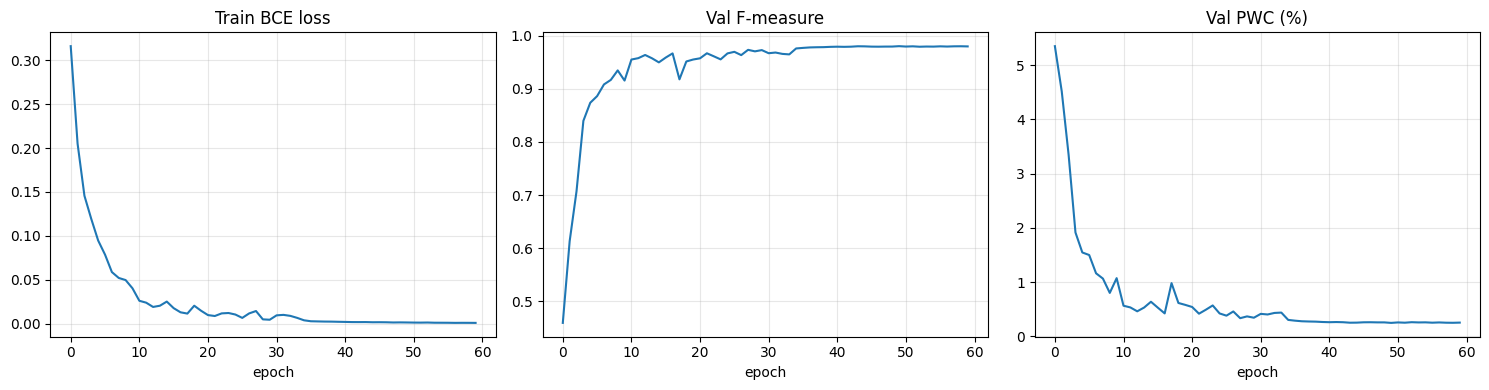

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history["train_loss"]); ax[0].set_title("Train BCE loss"); ax[0].set_xlabel("epoch")
ax[1].plot(history["val_f1"]);     ax[1].set_title("Val F-measure");  ax[1].set_xlabel("epoch")
ax[2].plot(history["val_pwc"]);    ax[2].set_title("Val PWC (%)");    ax[2].set_xlabel("epoch")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 15. Quantitative evaluation on held-out frames (per scene + overall)

In [19]:
import pandas as pd
model.eval(); rows = []; overall = SegMetrics()
with torch.no_grad():
    for sd in scene_dirs:
        scene = os.path.basename(sd)
        # val_frac=1.0 -> n_val = ALL annotated frames of the scene (proper full test)
        ds = CDDnetThermal([sd], CONFIG["img_size"], val_frac=1.0, split="val", seed=SEED)
        sm = SegMetrics()
        for x, label, valid, weight in torch.utils.data.DataLoader(ds, batch_size=8):
            x = x.to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                out = model(x)
            pred = (torch.sigmoid(out.float()) >= CONFIG["threshold"]).float().cpu().numpy()
            lbl, vld = label.numpy(), valid.numpy()
            for i in range(pred.shape[0]):
                sm.update(pred[i, 0], lbl[i, 0], vld[i, 0])
                overall.update(pred[i, 0], lbl[i, 0], vld[i, 0])
        r = sm.results(); r["Scene"] = scene; rows.append(r)
o = overall.results(); o["Scene"] = "OVERALL"; rows.append(o)
df = pd.DataFrame(rows)[["Scene", "Precision", "Recall", "F-measure", "PWC"]]
print(df.to_string(index=False))

# ---- inference speed (compare with paper's 24 fps) ----
import time
model.eval()
x0 = torch.rand(1, CONFIG["in_channels"], *CONFIG["img_size"], device=device)
with torch.no_grad():
    for _ in range(3):
        model(x0)                                   # warmup
    if device.type == "cuda":
        torch.cuda.synchronize()
    t0, n_it = time.time(), 20
    for _ in range(n_it):
        model(x0)
    if device.type == "cuda":
        torch.cuda.synchronize()
    dt_ms = (time.time() - t0) / n_it * 1000
    print(f"Inference: {1000.0/dt_ms:.1f} fps ({dt_ms:.0f} ms/frame) on {device}")

[val] 5400 frames from 1 scenes | corridor 5400
[val] 3700 frames from 1 scenes | diningRoom 3700
[val] 6500 frames from 1 scenes | lakeSide 6500
[val] 4900 frames from 1 scenes | library 4900
[val] 600 frames from 1 scenes | park 600
     Scene  Precision   Recall  F-measure      PWC
  corridor   0.981132 0.900549   0.939115 0.350895
diningRoom   0.981925 0.966143   0.973970 0.358561
  lakeSide   0.959101 0.941974   0.950460 0.158853
   library   0.997819 0.991666   0.994733 0.177090
      park   0.852556 0.860298   0.856409 0.341229
   OVERALL   0.989097 0.971246   0.980090 0.252712
Inference: 5.0 fps (200 ms/frame) on cuda


## 16. Qualitative results (input / GT / MSCP prediction)

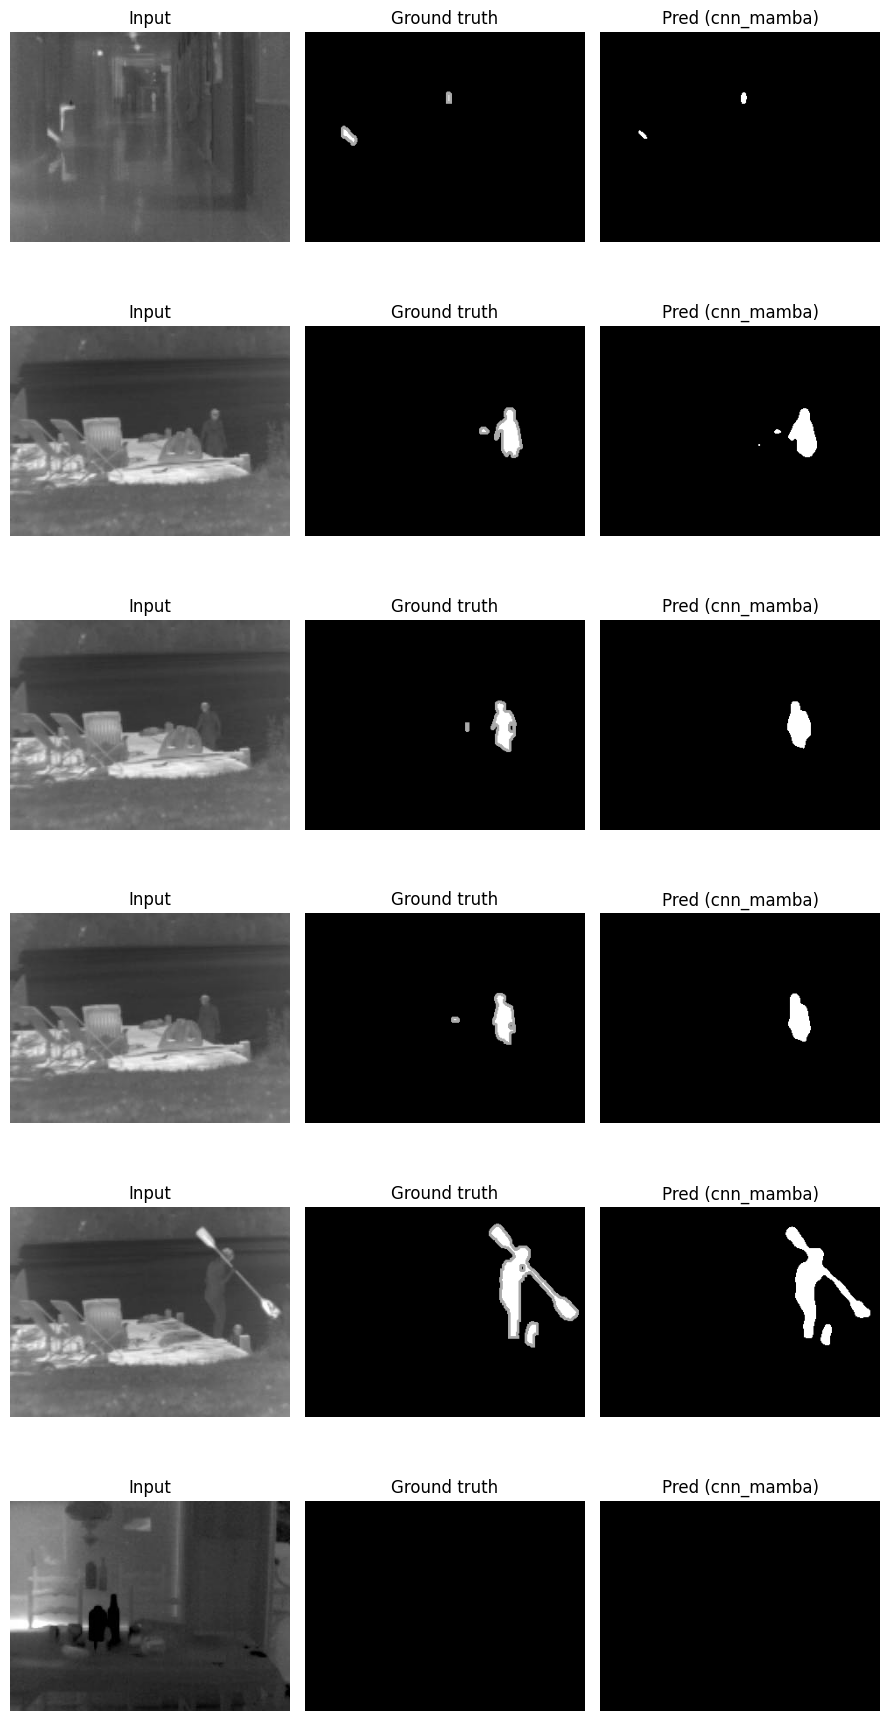

In [20]:
def overlay(mask, base):  # red overlay of predicted mask on the frame
    out = base.copy(); m = mask > 0.5
    out[m] = [0, 0, 255]; return out

model.eval()
samples = val_ds.pairs[:6] if len(val_ds.pairs) >= 6 else val_ds.pairs
fig, axs = plt.subplots(len(samples), 3, figsize=(9, 3 * len(samples)))
if len(samples) == 1: axs = axs[None, :]
for r, (fpath, gtpath, roipath) in enumerate(samples):
    H, W = CONFIG["img_size"]
    frame = cv2.resize(cv2.cvtColor(cv2.imread(fpath), cv2.COLOR_BGR2RGB), (W, H))
    gt = cv2.resize(cv2.imread(gtpath, cv2.IMREAD_GRAYSCALE), (W, H), interpolation=cv2.INTER_NEAREST)
    x = torch.from_numpy(frame.astype(np.float32) / 255.0).permute(2, 0, 1)[None].to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    pred = (prob >= CONFIG["threshold"]).astype(np.uint8)
    axs[r, 0].imshow(frame);        axs[r, 0].set_title("Input");      axs[r, 0].axis("off")
    axs[r, 1].imshow(gt, cmap="gray");  axs[r, 1].set_title("Ground truth"); axs[r, 1].axis("off")
    axs[r, 2].imshow(pred, cmap="gray");axs[r, 2].set_title(f"Pred ({CONFIG['arch']})");  axs[r, 2].axis("off")
plt.tight_layout(); plt.show()

## 17. Save checkpoint & results

In [21]:
os.makedirs("outputs", exist_ok=True)
torch.save({"state_dict": model.state_dict(), "config": CONFIG, "arch": CONFIG["arch"]},
           "outputs/mscp_mamba_balanced_cdnet2014.pth")
df.to_csv("outputs/cdnet2014_thermal_results_mamba_balanced.csv", index=False)
print("Saved outputs/mscp_mamba_balanced_cdnet2014.pth and outputs/cdnet2014_thermal_results_mamba_balanced.csv")

# also persist final artifacts to Drive
shutil.copy("outputs/mscp_mamba_balanced_cdnet2014.pth", os.path.join(DRIVE_DIR, "mscp_mamba_balanced_cdnet2014.pth"))
shutil.copy("outputs/cdnet2014_thermal_results_mamba_balanced.csv",
            os.path.join(DRIVE_DIR, "cdnet2014_thermal_results_mamba_balanced.csv"))
print("Copied final checkpoint + results ->", DRIVE_DIR)

Saved outputs/mscp_mamba_balanced_cdnet2014.pth and outputs/cdnet2014_thermal_results_mamba_balanced.csv
Copied final checkpoint + results -> /content/drive/MyDrive/mscp_mamba_balanced
